In [1]:
# Import library yang dibutuhkan
# pandas digunakan untuk membaca dan mengolah data
# numpy digunakan untuk operasi numerik
# matplotlib digunakan untuk visualisasi
# pathlib digunakan untuk mengatur path folder/file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Import SARIMAX untuk model forecasting dengan variabel eksternal
# Import metrics untuk evaluasi hasil forecast
# Import StandardScaler untuk scaling variabel eksternal

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Menentukan lokasi folder project
# PROCESSED_DIR = folder tempat master dataset disimpan
# FIGURES_DIR = folder untuk menyimpan grafik
# RESULTS_DIR = folder untuk menyimpan hasil model

BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
RESULTS_DIR = BASE_DIR / "reports" / "model_results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)
print("Model results directory:", RESULTS_DIR)

Processed directory: c:\Users\Project\skripsi\inflation-forecast-final\data\processed
Figures directory: c:\Users\Project\skripsi\inflation-forecast-final\reports\figures
Model results directory: c:\Users\Project\skripsi\inflation-forecast-final\reports\model_results


In [4]:
# Membaca master dataset yang sudah dibuat sebelumnya

master_df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")

master_df.head()

,date,inflation,bi_rate,exchange_rate,oil_price
0,2010-01-01,0.84,6.5,9270.000000,76.167368
1,2010-02-01,-0.08,6.5,9326.250000,73.752105
2,2010-03-01,-0.14,6.5,9161.086957,78.827391
3,2010-04-01,0.15,6.5,9026.318182,84.817619
4,2010-05-01,0.29,6.5,9160.238095,75.945500


In [5]:
# Mengubah kolom date menjadi datetime
# Lalu menjadikan date sebagai index karena data berbentuk time series bulanan

master_df["date"] = pd.to_datetime(master_df["date"])

master_df = master_df.set_index("date")

# Mengatur frekuensi data menjadi bulanan awal bulan
# MS = Month Start

master_df = master_df.asfreq("MS")

master_df.head()

,inflation,bi_rate,exchange_rate,oil_price
date,,,,
2010-01-01,0.84,6.5,9270.000000,76.167368
2010-02-01,-0.08,6.5,9326.250000,73.752105
2010-03-01,-0.14,6.5,9161.086957,78.827391
2010-04-01,0.15,6.5,9026.318182,84.817619
2010-05-01,0.29,6.5,9160.238095,75.945500


In [6]:
# Mengecek informasi dataset setelah date dijadikan index

master_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 192 entries, 2010-01-01 to 2025-12-01
Freq: MS
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   inflation      192 non-null    float64
 1   bi_rate        192 non-null    float64
 2   exchange_rate  192 non-null    float64
 3   oil_price      192 non-null    float64
dtypes: float64(4)
memory usage: 7.5 KB


In [7]:
# Mengecek ukuran dataset
# Expected: 192 baris dan 4 kolom karena date sudah menjadi index

master_df.shape

(192, 4)

In [8]:
# Mengecek missing value

master_df.isnull().sum()

inflation        0
bi_rate          0
exchange_rate    0
oil_price        0
dtype: int64

In [9]:
# Menentukan target variable
# Target yang akan diprediksi adalah inflation

target = master_df["inflation"]

# Menentukan exogenous variables
# Variabel eksternal yang digunakan adalah BI Rate, exchange rate, dan oil price

exog = master_df[["bi_rate", "exchange_rate", "oil_price"]]

target.head()

date
2010-01-01    0.84
2010-02-01   -0.08
2010-03-01   -0.14
2010-04-01    0.15
2010-05-01    0.29
Freq: MS, Name: inflation, dtype: float64

In [10]:
# Melihat beberapa baris awal variabel eksternal

exog.head()

,bi_rate,exchange_rate,oil_price
date,,,
2010-01-01,6.5,9270.000000,76.167368
2010-02-01,6.5,9326.250000,73.752105
2010-03-01,6.5,9161.086957,78.827391
2010-04-01,6.5,9026.318182,84.817619
2010-05-01,6.5,9160.238095,75.945500


In [11]:
# Membagi target menjadi train dan test

y_train = target.loc["2010-01-01":"2023-12-01"]
y_test = target.loc["2024-01-01":"2025-12-01"]

# Membagi variabel eksternal menjadi train dan test

exog_train = exog.loc["2010-01-01":"2023-12-01"]
exog_test = exog.loc["2024-01-01":"2025-12-01"]

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("exog_train shape:", exog_train.shape)
print("exog_test shape :", exog_test.shape)

y_train shape: (168,)
y_test shape : (24,)
exog_train shape: (168, 3)
exog_test shape : (24, 3)


In [12]:
# Melakukan scaling pada variabel eksternal
# Scaler hanya di-fit pada data train agar tidak terjadi data leakage

scaler = StandardScaler()

exog_train_scaled = scaler.fit_transform(exog_train)
exog_test_scaled = scaler.transform(exog_test)

# Mengubah hasil scaling kembali menjadi DataFrame agar index dan nama kolom tetap rapi

exog_train_scaled = pd.DataFrame(
    exog_train_scaled,
    index=exog_train.index,
    columns=exog_train.columns
)

exog_test_scaled = pd.DataFrame(
    exog_test_scaled,
    index=exog_test.index,
    columns=exog_test.columns
)

exog_train_scaled.head()

,bi_rate,exchange_rate,oil_price
date,,,
2010-01-01,0.651411,-1.499134,-0.069953
2010-02-01,0.651411,-1.474107,-0.164754
2010-03-01,0.651411,-1.547592,0.034455
2010-04-01,0.651411,-1.607553,0.269576
2010-05-01,0.651411,-1.547969,-0.078661


In [13]:
# Mengecek hasil scaling variabel eksternal train

exog_train_scaled.describe()

,bi_rate,exchange_rate,oil_price
count,1.680000e+02,168.000000,1.680000e+02
mean,-3.383537e-16,0.000000,-5.921189e-16
std,1.002990e+00,1.002990,1.002990e+00
min,-1.681174e+00,-1.832263,-2.338211e+00
25%,-7.092632e-01,-1.163444,-8.037848e-01
50%,6.826514e-02,0.328261,-9.524471e-02
75%,7.000069e-01,0.756989,9.879084e-01
max,1.623322e+00,1.443752,1.864251e+00


In [14]:
# Mengecek apakah ada missing value setelah scaling

print("Missing exog train:")
print(exog_train_scaled.isnull().sum())

print("\nMissing exog test:")
print(exog_test_scaled.isnull().sum())

Missing exog train:
bi_rate          0
exchange_rate    0
oil_price        0
dtype: int64

Missing exog test:
bi_rate          0
exchange_rate    0
oil_price        0
dtype: int64


In [15]:
# Menentukan beberapa kandidat order SARIMAX
# Nilai d = 0 karena data inflasi sudah stationer berdasarkan ADF Test sebelumnya
# Kandidat order mengikuti kandidat ARIMA agar perbandingan lebih konsisten

candidate_orders = [
    (1, 0, 0),
    (2, 0, 0),
    (0, 0, 1),
    (0, 0, 2),
    (1, 0, 1),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2),
    (3, 0, 1),
    (3, 0, 2)
]

sarimax_results = []

for order in candidate_orders:
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train_scaled,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        sarimax_results.append({
            "order": order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic
        })

    except Exception as e:
        print(f"SARIMAX{order} failed: {e}")

In [16]:
# Mengubah hasil kandidat SARIMAX menjadi DataFrame
# AIC dan BIC yang lebih kecil menunjukkan model yang lebih baik secara statistik

sarimax_results_df = pd.DataFrame(sarimax_results)

sarimax_results_df = sarimax_results_df.sort_values(by="AIC")

sarimax_results_df

,order,AIC,BIC
8,"(3, 0, 1)",182.019633,206.867197
9,"(3, 0, 2)",183.059258,211.012767
6,"(1, 0, 2)",193.921679,215.663297
7,"(2, 0, 2)",195.544407,220.391971
4,"(1, 0, 1)",224.780167,243.452094
3,"(0, 0, 2)",225.715562,244.351235
1,"(2, 0, 0)",225.981244,244.653171
5,"(2, 0, 1)",226.772694,248.556608
0,"(1, 0, 0)",229.555719,245.145688
2,"(0, 0, 1)",229.624692,245.184631


In [17]:
# Membuat model SARIMAX terbaik berdasarkan hasil AIC dan BIC
# Model yang dipilih adalah SARIMAX(3, 0, 1)
# Model ini menggunakan inflation sebagai target
# dan bi_rate, exchange_rate, oil_price sebagai variabel eksternal

best_sarimax_order = (3, 0, 1)

sarimax_model = SARIMAX(
    y_train,
    exog=exog_train_scaled,
    order=best_sarimax_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fitted = sarimax_model.fit(disp=False)

sarimax_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              inflation   No. Observations:                  168
Model:               SARIMAX(3, 0, 1)   Log Likelihood                 -83.010
Date:                Mon, 15 Jun 2026   AIC                            182.020
Time:                        14:38:43   BIC                            206.867
Sample:                    01-01-2010   HQIC                           192.106
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
bi_rate           0.0250      0.060      0.417      0.677      -0.092       0.142
exchange_rate     0.0339      0.226      0.150      0.881      -0.410       0.478
oil_price         0.0580      0.052      1.118      0.263      -0.044       0.160
ar.L1             1.4114      0.058     24.192      0.000       1.297       1.526
ar.L2            -0.7899      0.117     -6.726      0.000      -1.020      -0.560
ar.L3             0.3733      0.084      4.449      0.000       0.209       0.538
ma.L1            -1.0000     29.179     -0.034      0.973     -58.189      56.189
sigma2            0.1552      4.530      0.034      0.973      -8.724       9.035
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):               699.44
Prob(Q):                              0.44   Prob(JB):                         0.00
Heteroskedasticity (H):               0.42   Skew:                             1.84
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [18]:
# Melakukan forecasting sebanyak jumlah data test
# Pada SARIMAX, forecast membutuhkan exogenous variables untuk periode test

forecast_steps = len(y_test)

sarimax_forecast = sarimax_fitted.forecast(
    steps=forecast_steps,
    exog=exog_test_scaled
)

# Menyesuaikan index forecast dengan index data test
# Agar actual dan forecast berada pada tanggal yang sama

sarimax_forecast = pd.Series(
    sarimax_forecast.values,
    index=y_test.index,
    name="sarimax_forecast"
)

sarimax_forecast.head()

date
2024-01-01    0.290476
2024-02-01    0.228933
2024-03-01    0.251029
2024-04-01    0.303767
2024-05-01    0.291643
Freq: MS, Name: sarimax_forecast, dtype: float64

In [19]:
# Membuat tabel perbandingan antara nilai aktual dan hasil forecast SARIMAX

sarimax_result_df = pd.DataFrame({
    "actual": y_test,
    "forecast": sarimax_forecast
})

sarimax_result_df.head()

,actual,forecast
date,,
2024-01-01,0.04,0.290476
2024-02-01,0.37,0.228933
2024-03-01,0.52,0.251029
2024-04-01,0.25,0.303767
2024-05-01,-0.03,0.291643


In [20]:
# Melihat beberapa baris akhir hasil forecast SARIMAX

sarimax_result_df.tail()

,actual,forecast
date,,
2025-08-01,-0.08,0.210149
2025-09-01,0.21,0.207681
2025-10-01,0.28,0.200309
2025-11-01,0.17,0.199035
2025-12-01,0.64,0.195235


In [21]:
# Menghitung MAE dan RMSE untuk model SARIMAX
# MAE menunjukkan rata-rata kesalahan absolut
# RMSE memberikan penalti lebih besar pada error yang besar

sarimax_mae = mean_absolute_error(
    sarimax_result_df["actual"],
    sarimax_result_df["forecast"]
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        sarimax_result_df["actual"],
        sarimax_result_df["forecast"]
    )
)

print("SARIMAX Order:", best_sarimax_order)
print("MAE:", sarimax_mae)
print("RMSE:", sarimax_rmse)

SARIMAX Order: (3, 0, 1)
MAE: 0.3571274932717685
RMSE: 0.4980008433177768


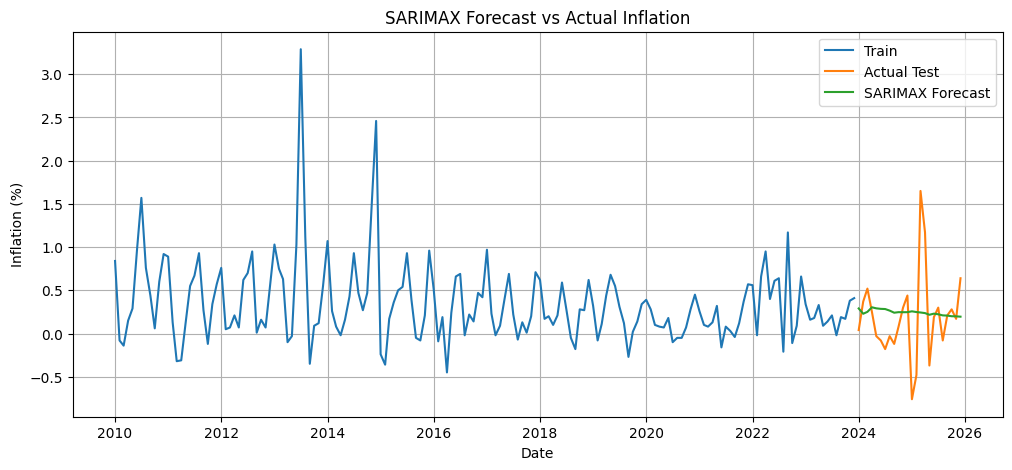

In [22]:
# Visualisasi perbandingan data aktual dan hasil forecast SARIMAX

plt.figure(figsize=(12, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Test"
)

plt.plot(
    sarimax_forecast.index,
    sarimax_forecast,
    label="SARIMAX Forecast"
)

plt.title("SARIMAX Forecast vs Actual Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)
plt.show()

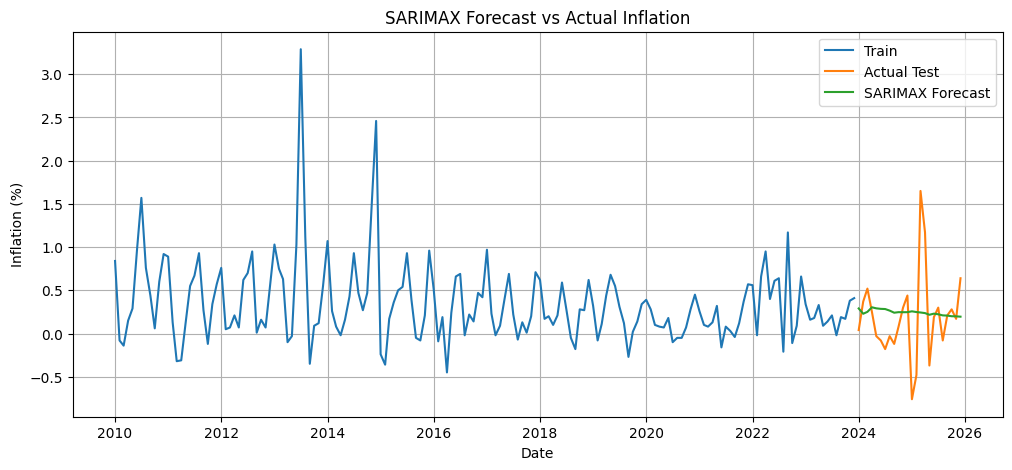

In [23]:
# Menyimpan grafik hasil forecast SARIMAX ke folder reports/figures

plt.figure(figsize=(12, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Test"
)

plt.plot(
    sarimax_forecast.index,
    sarimax_forecast,
    label="SARIMAX Forecast"
)

plt.title("SARIMAX Forecast vs Actual Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURES_DIR / "sarimax_forecast_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Menyimpan hasil actual vs forecast SARIMAX
# File ini akan digunakan untuk perbandingan model nanti

sarimax_forecast_results = sarimax_result_df.reset_index()

sarimax_forecast_results["model"] = "SARIMAX"
sarimax_forecast_results["order"] = str(best_sarimax_order)

sarimax_forecast_results.to_csv(
    RESULTS_DIR / "sarimax_forecast_results.csv",
    index=False
)

sarimax_forecast_results.head()

,date,actual,forecast,model,order
0,2024-01-01,0.04,0.290476,SARIMAX,"(3, 0, 1)"
1,2024-02-01,0.37,0.228933,SARIMAX,"(3, 0, 1)"
2,2024-03-01,0.52,0.251029,SARIMAX,"(3, 0, 1)"
3,2024-04-01,0.25,0.303767,SARIMAX,"(3, 0, 1)"
4,2024-05-01,-0.03,0.291643,SARIMAX,"(3, 0, 1)"


In [25]:
# Menyimpan hasil evaluasi SARIMAX
# MAE dan RMSE nanti akan dibandingkan dengan ARIMA dan XGBoost

sarimax_metrics_df = pd.DataFrame({
    "model": ["SARIMAX"],
    "order": [str(best_sarimax_order)],
    "mae": [sarimax_mae],
    "rmse": [sarimax_rmse]
})

sarimax_metrics_df.to_csv(
    RESULTS_DIR / "sarimax_metrics.csv",
    index=False
)

sarimax_metrics_df

,model,order,mae,rmse
0,SARIMAX,"(3, 0, 1)",0.357127,0.498001


In [26]:
# Menyimpan summary model SARIMAX dalam bentuk file text

with open(RESULTS_DIR / "sarimax_model_summary.txt", "w") as f:
    f.write(str(sarimax_fitted.summary()))

print("SARIMAX model summary saved.")

SARIMAX model summary saved.


In [27]:
# Mengecek file hasil SARIMAX yang sudah tersimpan

list(RESULTS_DIR.glob("sarimax*"))

[WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/model_results/sarimax_forecast_results.csv'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/model_results/sarimax_metrics.csv'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/model_results/sarimax_model_summary.txt')]

In [28]:
print("SARIMAX Order:", best_sarimax_order)
print("MAE:", sarimax_mae)
print("RMSE:", sarimax_rmse)

SARIMAX Order: (3, 0, 1)
MAE: 0.3571274932717685
RMSE: 0.4980008433177768
